# Running my own implementation of a SVM

In [142]:
%load_ext autoreload
%autoreload 2
#this will import new versions of the code

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [143]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath("..")) #need to do this to find src
from src.models.svm import SVM
import matplotlib.pyplot as plt

def decision_boundary(model, X, label):
    # Create the grid
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100),
        np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict on the grid
    Z = np.array(model.predict(grid))
    Z = Z.reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, levels=[-1,0,1], cmap=plt.cm.PuBu, alpha=0.3)  # background
    plt.title(f"{label} with Decision Boundary")
    plt.show()

In [144]:
x = np.array([
    [2, 5],
    [1.5, 2.5],
    [3, 4],  
    [4, 5],
    [1, 1],
    [0.5, 4],
    [0,2],

    [2, 0],
    [4, 1],
    [4, 2], 
    [5, 2],
    [3, -1],
    [5, -1.5],
])

y = np.array([
    1, 1, 1, 1, 1, 1,1,
    -1, -1, -1, -1, -1, -1
])

# Define our kernel (for now we will use a linear kernel):
def kernel(a, b):
    return np.dot(a, b)

# Initialize and train the SVM
svm = SVM(kernel, 0.1, 1)
svm.fit(x, y)

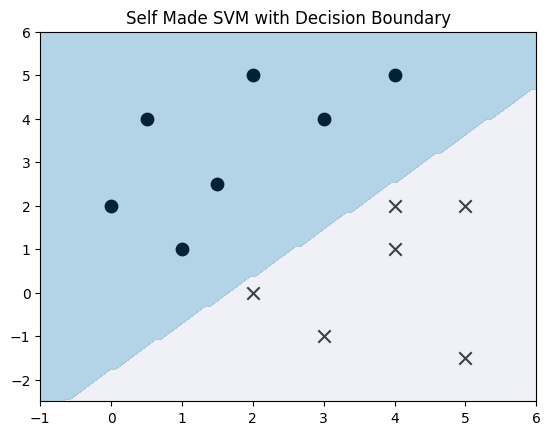

In [145]:
plt.scatter(x[y==1,0], x[y==1,1], marker='o', s=80, c='k')
plt.scatter(x[y==-1,0], x[y==-1,1], marker='x', s=80, c='k')
decision_boundary(svm, x, "Self Made SVM")